# Business Requirements Document (BRD)
## Project: Pizza Sales Analysis
#### Project Overview
    The Pizza Sales Analysis project is designed to analyse transactional sales data from a pizza store. The goal is to identify key business insights, trends, and KPIs that will help management make informed decisions related to sales, marketing, and operations.

#### Business Objectives
    - Identify overall revenue, total pizzas sold, and total number of orders.
    - Determine sales distribution by pizza category, size, and type.
    - Analyse time-based trends in sales (daily, monthly, and yearly).
    - Highlight best-selling and least-selling pizzas by revenue and quantity.
    - Understand customer purchasing behaviour through Average Order Value (AOV) and Average Pizza per Order.
    - Provide visualization dashboards for effective decision-making.

#### Data Source & Description
    Dataset: pizza_sales.csv
    Key fields:
        order_id → Unique identifier for each order
        pizza_id → Unique identifier for each pizza
        pizza_name → Name of the pizza sold
        quantity → Number of pizzas sold per order
        total_price → Total revenue for each transaction
        date, time → Order timestamp for time-based analysis
        pizza_category, pizza_size → Attributes for pizza classification

#### Key Performance Indicators (KPIs)
    Total Revenue = Sum of total_price
    Total Pizzas Sold = Sum of quantity
    Total Orders = Count of unique order_id
    Average Order Value (AOV) = Total Revenue ÷ Total Orders
    Average Pizza per Order = Total Pizzas Sold ÷ Total Orders

#### Analysis & Visualizations
    Ingredient Analysis
        The pizza business aims to understand which ingredients are most frequently used across different pizza types. By identifying the most common ingredients, the store can use.

    Daily Trend
        A line/bar chart showing sales by day of the week.
            - Useful for staffing and operations planning.
    
    Hourly Trend
        A line/bar chart showing sales by hour of the day.
        Useful for staffing, ingredients, customer rush and operations planning

    Monthly Trend
        A line chart depicting monthly revenue and orders.
            - Helps track seasonality and identify peak sales months.
            - Summer months show higher sales due to promotional campaigns.

    % of Sales by Category
        A bar chart representing revenue and quantity sold for each pizza category (Classic, Supreme, Veggie, Chicken).
            - Helps identify customer preferences.
            - Classic pizzas dominate sales, while Veggie has lower demand.

    % Sales by Pizza Size & Category
        A bar/ donut chart comparing sales revenue and quantity by pizza size (S, M, L, XL).
            - Highlights demand distribution by size and assist inventory planning.
            - Large (L) pizzas contribute the highest revenue.

    Total Pizzas Sold by Pizza Category
        - Manage inventory by stocking ingredients used in the most popular categories.
        - Evaluate if low-performing categories should be optimized, redesigned, or discontinued.

    Top 5 Best-Selling Pizzas
        A horizontal bar chart showing pizzas with the highest sales (by revenue, orders or quantity).
            - Supports promotional and menu strategy.

    Bottom 5 Least-Selling Pizzas
        A horizontal bar chart of pizzas with the lowest sales.
            - Identifies products for improvement or possible removal from the menu.

#### Business Questions Answered
    What is the total revenue generated?
    How many pizzas were sold in total?
    Which category and size of pizzas perform best?
    Which pizzas are the top and bottom performers?
    What is the average order value and average pizzas per order?
    What are the sales trends by day, month, and time of day?

#### Deliverables
    - Jupyter Notebook with complete Python analysis.
    - Visualizations (bar charts, line charts, trend charts).
    - Business Requirements Document (BRD).
    - Insights and recommendations for management.

#### Conclusion & Recommendations
    The analysis provides a comprehensive view of pizza sales performance. Management can leverage these insights to:
        - Focus marketing on high-performing categories.
        - Optimize the menu by reconsidering least-selling pizzas.
        - Plan inventory and staffing based on sales peaks.
        - Monitor KPIs regularly through dashboards for continuous improvement.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('pizza_sales.csv')
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [3]:
df.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

In [4]:
# Check duplicates
duplicate_data = df[df['pizza_id'].duplicated()]
duplicate_data

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  str    
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  str    
 5   order_time         48620 non-null  str    
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  str    
 9   pizza_category     48620 non-null  str    
 10  pizza_ingredients  48620 non-null  str    
 11  pizza_name         48620 non-null  str    
dtypes: float64(2), int64(3), str(7)
memory usage: 10.4 MB


In [6]:
# change into datetime format
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed')
df['order_time'] = pd.to_datetime(df['order_time'], format='mixed')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   pizza_id           48620 non-null  int64         
 1   order_id           48620 non-null  int64         
 2   pizza_name_id      48620 non-null  str           
 3   quantity           48620 non-null  int64         
 4   order_date         48620 non-null  datetime64[us]
 5   order_time         48620 non-null  datetime64[us]
 6   unit_price         48620 non-null  float64       
 7   total_price        48620 non-null  float64       
 8   pizza_size         48620 non-null  str           
 9   pizza_category     48620 non-null  str           
 10  pizza_ingredients  48620 non-null  str           
 11  pizza_name         48620 non-null  str           
dtypes: datetime64[us](2), float64(2), int64(3), str(5)
memory usage: 9.6 MB


### Feature Engineering

In [8]:
# extract day and month
df['order_day'] = df['order_date'].dt.day_name()
df['month_num'] = df['order_date'].dt.month
df['order_month'] = df['order_date'].dt.month_name()

# extract hour
df['order_hour'] = df['order_time'].dt.hour

In [9]:
df

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,order_day,month_num,order_month,order_hour
0,1,1,hawaiian_m,1,2015-01-01,2026-09-22 11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,Thursday,1,January,11
1,2,2,classic_dlx_m,1,2015-01-01,2026-09-22 11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,Thursday,1,January,11
2,3,2,five_cheese_l,1,2015-01-01,2026-09-22 11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,Thursday,1,January,11
3,4,2,ital_supr_l,1,2015-01-01,2026-09-22 11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza,Thursday,1,January,11
4,5,2,mexicana_m,1,2015-01-01,2026-09-22 11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,Thursday,1,January,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,2015-12-31,2026-09-22 21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza,Thursday,12,December,21
48616,48617,21348,four_cheese_l,1,2015-12-31,2026-09-22 21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza,Thursday,12,December,21
48617,48618,21348,napolitana_s,1,2015-12-31,2026-09-22 21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza,Thursday,12,December,21
48618,48619,21349,mexicana_l,1,2015-12-31,2026-09-22 22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,Thursday,12,December,22


### Analysis
## KPI

In [10]:
total_revenue = df['total_price'].sum()
total_pizza_sold = df['quantity'].sum()
total_orders = df['order_id'].nunique()
average_order_value = total_revenue / total_orders
average_pizza_per_order = total_pizza_sold / total_orders

In [11]:
print(f'Total Revenue: Rs.{total_revenue:,.2f}')
print(f'Total Pizza Sold: {total_pizza_sold} qty.')
print(f'Total Orders: {total_orders}')
print(f'Average Order Value: Rs.{average_order_value:,.2f}')
print(f'Average Pizza Per Order: {average_pizza_per_order:,.2f} qty.')

Total Revenue: Rs.817,860.05
Total Pizza Sold: 49574 qty.
Total Orders: 21350
Average Order Value: Rs.38.31
Average Pizza Per Order: 2.32 qty.


#### Functions

In [12]:
# currency converter
def currencyConverter(dataframe, prefix, *args):
    for col in args:
        dataframe[col] = dataframe[col].map(f"{prefix}"'{:,.2f}'.format)

# percentage converter
def pctConverter(dataframe, *args):
    for col in args:
        dataframe[col] = dataframe[col].map('{:,.2f}%'.format)

## Sales by Day of Week

In [13]:
weekday = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
df['order_day'] = pd.Categorical(df['order_day'], categories=weekday)

In [14]:
day_sales = df.groupby('order_day', observed=False)['total_price'].sum().reset_index().rename(
    columns = {'order_day': 'Order Day', 'total_price': 'Total Price'}
)
currencyConverter(day_sales, 'Rs.', 'Total Price')
day_sales

,Order Day,Total Price
0,Sunday,"Rs.102,116.45"
1,Monday,"Rs.110,471.60"
2,Tuesday,"Rs.115,594.45"
3,Wednesday,"Rs.116,731.20"
4,Thursday,"Rs.121,650.30"
5,Friday,"Rs.129,690.90"
6,Saturday,"Rs.121,605.15"


## Sales by Hour of Day

In [15]:
hour_sales = df.groupby('order_hour')['total_price'].sum().reset_index().rename(
    columns = {'order_hour': 'Order Hour', 'total_price': 'Total Price'}
)
currencyConverter(hour_sales, 'Rs.', 'Total Price')
hour_sales

,Order Hour,Total Price
0,9,Rs.83.00
1,10,Rs.303.65
2,11,"Rs.44,935.80"
3,12,"Rs.111,877.90"
4,13,"Rs.106,065.70"
5,14,"Rs.59,201.40"
6,15,"Rs.52,992.30"
7,16,"Rs.70,055.40"
8,17,"Rs.86,237.45"
9,18,"Rs.89,296.85"


## Monthly Trend

In [16]:
monthly_sales = df.groupby(['month_num', 'order_month']).agg(
    Total_Price = ('total_price', 'sum'),
    Total_Orders = ('order_id', 'nunique')
).reset_index().rename(columns = {'order_month': 'Order Month', 'Total_Price': 'Total Price', 'Total_Orders': 'Total Orders'})
currencyConverter(monthly_sales, 'Rs.', 'Total Price')
monthly_sales[['Order Month', 'Total Price', 'Total Orders']]

,Order Month,Total Price,Total Orders
0,January,"Rs.71,620.15",1929
1,February,"Rs.64,419.45",1648
2,March,"Rs.71,301.40",1864
3,April,"Rs.70,312.00",1829
4,May,"Rs.67,648.80",1765
5,June,"Rs.68,161.45",1771
6,July,"Rs.70,880.65",1860
7,August,"Rs.69,497.30",1835
8,September,"Rs.63,803.70",1638
9,October,"Rs.68,152.20",1782


## % of Sales by Category

In [17]:
pct_category_sales = df.groupby('pizza_category')['total_price'].sum().reset_index().rename(
    columns = {'pizza_category': 'Pizza Category', 'total_price': 'Total Price'}
)
pct_category_sales['%Sales'] = (pct_category_sales['Total Price']/total_revenue)*100

currencyConverter(pct_category_sales, 'Rs.', 'Total Price')
pctConverter(pct_category_sales, '%Sales')

pct_category_sales
# pct_category_sales[['Pizza Category', '%Sales']]

,Pizza Category,Total Price,%Sales
0,Chicken,"Rs.195,919.50",23.96%
1,Classic,"Rs.220,053.10",26.91%
2,Supreme,"Rs.208,197.00",25.46%
3,Veggie,"Rs.193,690.45",23.68%


## % of Sales by Pizza Size & Category

In [18]:
pct_size_cat = df.groupby(['pizza_size', 'pizza_category'])['total_price'].sum().reset_index().rename(
    columns = {'pizza_size': 'Pizza Size', 'pizza_category': 'Pizza Category', 'total_price': 'Total Price'}
)
pct_size_cat['Sales%'] = (pct_size_cat['Total Price']/total_revenue)*100

currencyConverter(pct_size_cat, 'Rs.', 'Total Price')
pctConverter(pct_size_cat, 'Sales%')

pct_size_cat[['Pizza Size', 'Pizza Category', 'Sales%']]

,Pizza Size,Pizza Category,Sales%
0,L,Chicken,12.51%
1,L,Classic,9.11%
2,L,Supreme,11.53%
3,L,Veggie,12.74%
4,M,Chicken,7.98%
5,M,Classic,7.41%
6,M,Supreme,8.13%
7,M,Veggie,6.98%
8,S,Chicken,3.47%
9,S,Classic,8.54%


## Total Pizza Sold by Pizza Category

In [19]:
quantity_category = df.groupby('pizza_category')['quantity'].sum().reset_index().rename(
    columns = {'pizza_category': 'Pizza Category', 'quantity': 'Quantity'}
)

quantity_category

,Pizza Category,Quantity
0,Chicken,11050
1,Classic,14888
2,Supreme,11987
3,Veggie,11649


## Top 5 Best Selling Pizza

In [20]:
top_5 = df.groupby('pizza_name')['total_price'].sum().reset_index().rename(
    columns = {'pizza_name': 'Pizza Name', 'total_price': 'Total Price'}
).sort_values(
    ascending=False, by='Total Price', ignore_index=True
).head()
currencyConverter(top_5, 'Rs.', 'Total Price')
top_5

,Pizza Name,Total Price
0,The Thai Chicken Pizza,"Rs.43,434.25"
1,The Barbecue Chicken Pizza,"Rs.42,768.00"
2,The California Chicken Pizza,"Rs.41,409.50"
3,The Classic Deluxe Pizza,"Rs.38,180.50"
4,The Spicy Italian Pizza,"Rs.34,831.25"


## Bottom 5 Least Selling Pizza

In [21]:
bottom_5 = df.groupby('pizza_name')['total_price'].sum().reset_index().rename(
    columns = {'pizza_name': 'Pizza Name', 'total_price': 'Total Price'}
).sort_values(
    ascending=True, by='Total Price', ignore_index=True
).head()
currencyConverter(bottom_5, 'Rs.', 'Total Price')
bottom_5

,Pizza Name,Total Price
0,The Brie Carre Pizza,"Rs.11,588.50"
1,The Green Garden Pizza,"Rs.13,955.75"
2,The Spinach Supreme Pizza,"Rs.15,277.75"
3,The Mediterranean Pizza,"Rs.15,360.50"
4,The Spinach Pesto Pizza,"Rs.15,596.00"


# Visualization

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sales by Day of Week

In [23]:
day_sales = df.groupby('order_day', observed=False)['total_price'].sum().reset_index().rename(
    columns = {'order_day': 'Order Day', 'total_price': 'Total Price'}
)

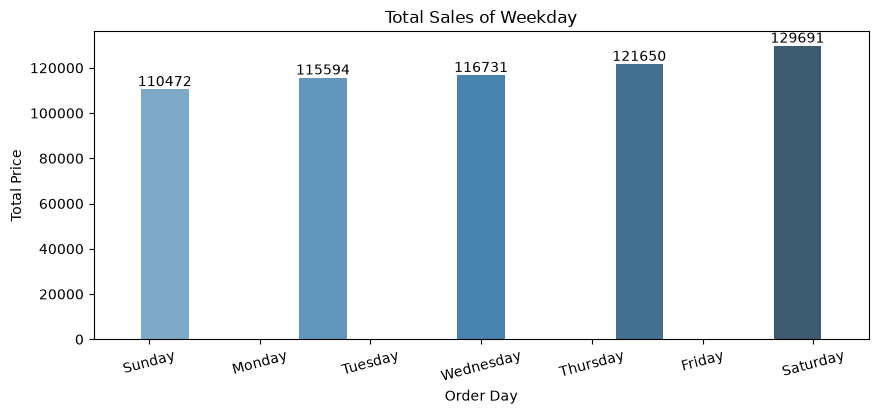

In [24]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(data=day_sales, x='Order Day', y='Total Price', palette='Blues_d', hue='Order Day', width=3)
plt.xticks(rotation=15)
plt.title('Total Sales of Weekday')
for container in ax.containers:
    plt.bar_label(container)

plt.show()

# Sales by Hour of Day

In [25]:
hour_sales = df.groupby('order_hour')['total_price'].sum().reset_index().rename(
    columns = {'order_hour': 'Order Hour', 'total_price': 'Total Price'}
)

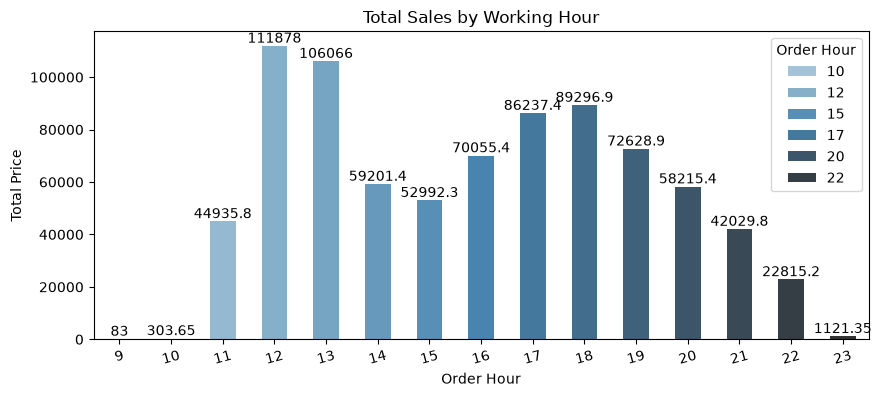

In [26]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(data=hour_sales, x='Order Hour', y='Total Price', palette='Blues_d', hue='Order Hour', width=0.5)
plt.xticks(rotation=15)
plt.title('Total Sales by Working Hour')

for container in ax.containers:
    plt.bar_label(container)

plt.show()

# Monthly Sales

In [27]:
monthly_sales = df.groupby(['month_num', 'order_month']).agg(
    Total_Price = ('total_price', 'sum'),
    Total_Orders = ('order_id', 'nunique')
).reset_index().rename(columns = {'order_month': 'Order Month', 'Total_Price': 'Total Price', 'Total_Orders': 'Total Orders'})[[
    'Order Month', 'Total Price', 'Total Orders'
]]

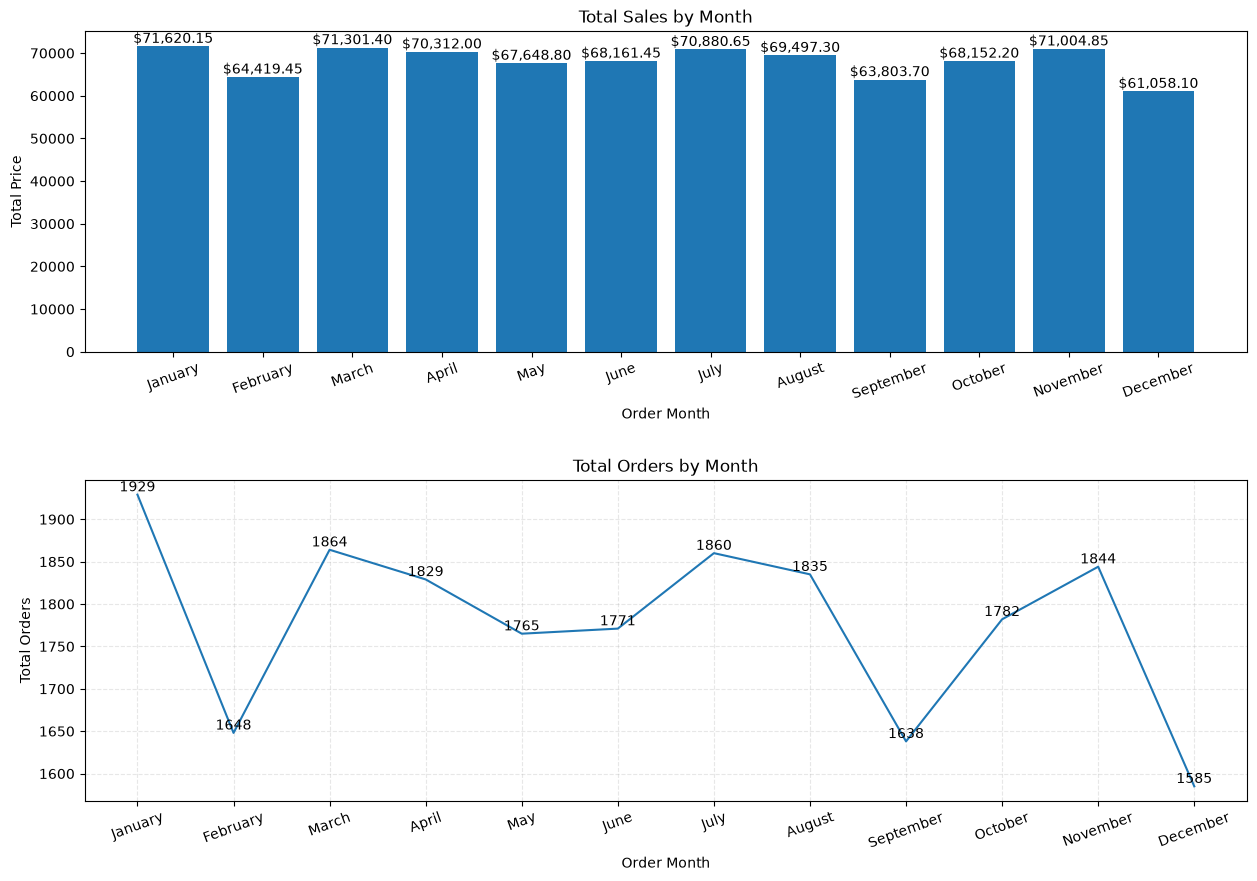

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
plt.subplots_adjust(hspace=0.4)

ax1 = axes[0]
ax1.bar(monthly_sales['Order Month'], monthly_sales['Total Price'])
ax1.set_xlabel('Order Month')
ax1.set_ylabel('Total Price')
ax1.set_title('Total Sales by Month')
ax1.tick_params(axis='x', rotation=20)

for idx, val in enumerate(monthly_sales['Total Price']):
    ax1.text(idx, val, f'${val:,.2f}', ha='center', va='bottom')


ax2 = axes[1]
ax2.plot(monthly_sales['Order Month'], monthly_sales['Total Orders'])
ax2.set_xlabel('Order Month')
ax2.set_ylabel('Total Orders')
ax2.set_title('Total Orders by Month')
ax2.grid(linestyle='dashed', alpha=0.3)

ax2.tick_params(axis='x', rotation=20)

for idx, val in enumerate(monthly_sales['Total Orders']):
    ax2.text(idx, val, f'{val}', ha='center', va='bottom')

# % of Sales by Category

In [29]:
pct_category_sales = df.groupby('pizza_category')['total_price'].sum().reset_index().rename(
    columns = {'pizza_category': 'Pizza Category', 'total_price': 'Total Price'}
)
pct_category_sales['%Sales'] = (pct_category_sales['Total Price']/total_revenue)*100

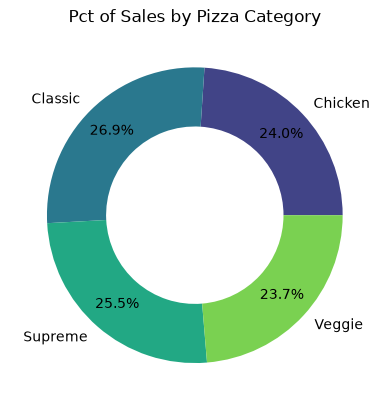

In [30]:
colors = sns.color_palette('viridis', len(pct_category_sales))
plt.pie(
    pct_category_sales['Total Price'],
    labels=pct_category_sales['Pizza Category'],
    autopct='%1.1f%%',
    wedgeprops={'width': 0.4},
    pctdistance=0.8,
    colors=colors
)
plt.title('Pct of Sales by Pizza Category')
plt.show()

# % of Sales by Pizza Size and Category

In [31]:
pct_size_cat = df.groupby(['pizza_size', 'pizza_category'])['total_price'].sum().reset_index().rename(
    columns = {'pizza_size': 'Pizza Size', 'pizza_category': 'Pizza Category', 'total_price': 'Total Price'}
)
pct_size_cat['Sales%'] = (pct_size_cat['Total Price']/total_revenue)*100

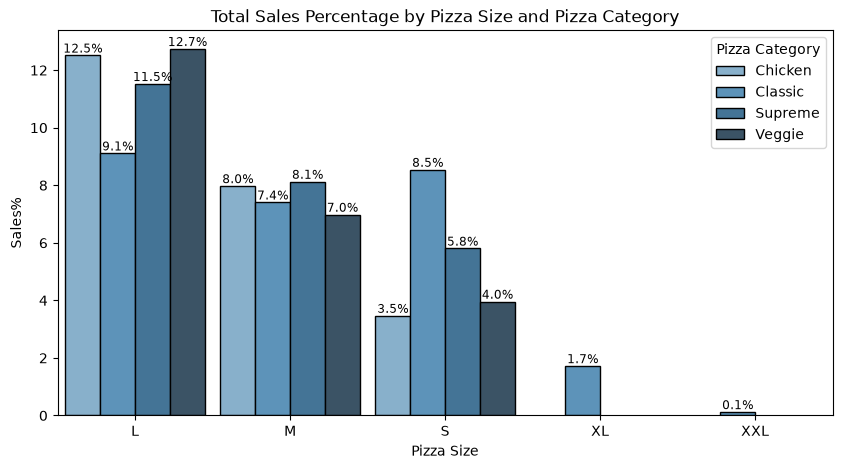

In [32]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=pct_size_cat, x='Pizza Size', y='Sales%', hue='Pizza Category', palette='Blues_d', 
                 edgecolor='black', width=0.9)
plt.title('Total Sales Percentage by Pizza Size and Pizza Category')

for container in ax.containers:
    plt.bar_label(container, fmt='%1.1f%%', fontsize='small')

# Total Pizza Sold by Pizza Category

In [33]:
quantity_category = df.groupby('pizza_category')['quantity'].sum().reset_index().rename(
    columns = {'pizza_category': 'Pizza Category', 'quantity': 'Quantity'}
)

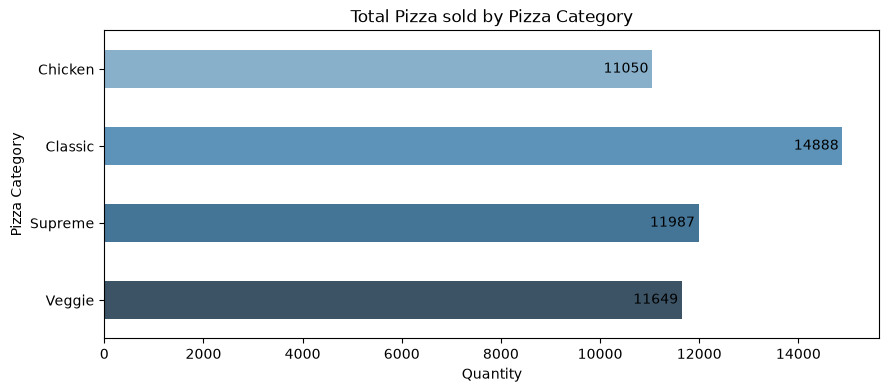

In [34]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(data=quantity_category, x='Quantity', y='Pizza Category', width=0.5, palette='Blues_d', hue='Pizza Category')
plt.title('Total Pizza sold by Pizza Category')

for container in ax.containers:
    plt.bar_label(container, label_type='edge', padding=-35)

plt.show()

# Top 5 Best Selling Pizza

In [35]:
top_5 = df.groupby('pizza_name')['total_price'].sum().reset_index().rename(
    columns = {'pizza_name': 'Pizza Name', 'total_price': 'Total Price'}
).sort_values(
    ascending=False, by='Total Price', ignore_index=True
).head()

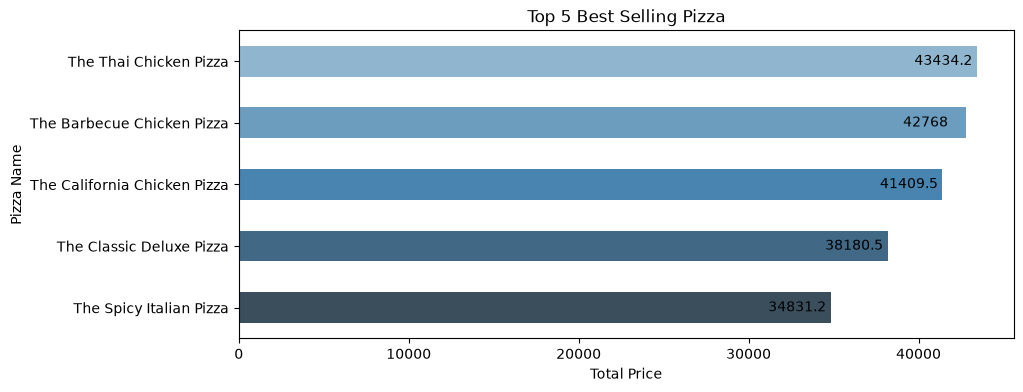

In [36]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(data=top_5, x='Total Price', y='Pizza Name', width=0.5, palette='Blues_d', hue='Pizza Name')
plt.title('Top 5 Best Selling Pizza')

for container in ax.containers:
    plt.bar_label(container, label_type='edge', padding=-45)

plt.show()

# Bottom 5 Least Selling Pizza

In [37]:
bottom_5 = df.groupby('pizza_name')['total_price'].sum().reset_index().rename(
    columns = {'pizza_name': 'Pizza Name', 'total_price': 'Total Price'}
).sort_values(
    ascending=True, by='Total Price', ignore_index=True
).head()

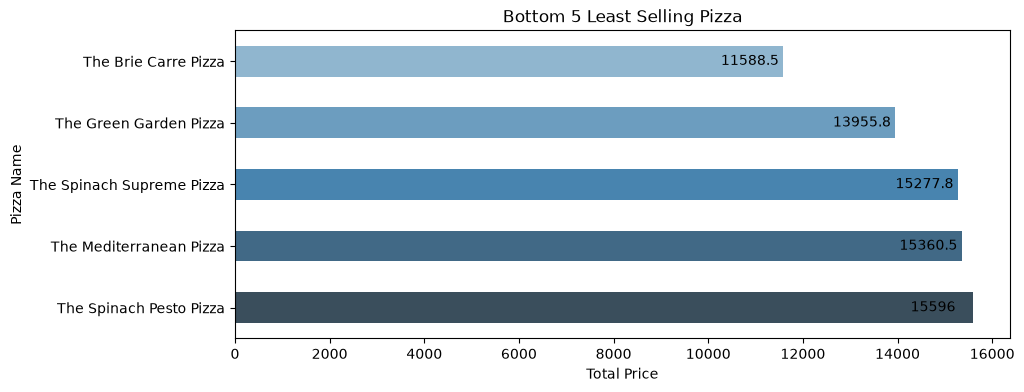

In [38]:
plt.figure(figsize=(10, 4))
ax = sns.barplot(data=bottom_5, x='Total Price', y='Pizza Name', width=0.5, palette='Blues_d', hue='Pizza Name')
plt.title('Bottom 5 Least Selling Pizza')

for container in ax.containers:
    plt.bar_label(container, label_type='edge', padding=-45)

plt.show()